In [1]:
%load_ext autoreload
%autoreload 2

In [23]:
import numpy as np
import random
from itertools import product
from dataclasses import dataclass
import matplotlib.pyplot as plt
from multiarm_bandits import *

In [24]:
def run_experiments(k, epsilon, bandits, alpha=None, steps=1000, nums=200):
    karm_bandits = NonstationaryKArmBandits(k, epsilon, bandits, alpha)
    reward_result = []
    optimal_ratio_result = []
    for _ in range(nums):
        karm_bandits.reset()
        avg_reward, optimal_ratio = karm_bandits.play(steps)
        reward_result.append(avg_reward)
        optimal_ratio_result.append(optimal_ratio)
    
    return np.array(reward_result), np.array(optimal_ratio_result)

def label(epsilon, alpha):
    if alpha is None:
        return f"epsilon={epsilon}, alpha=None (sample avg)"
    return f"epsilon={epsilon}, alpha={alpha}"

In [25]:
config = KArmNonstationaryBanditsConfig(
    k=10, reward=1.0, reward_std=0.5
)

bandits = initialize_nonstationary_bandits(config)

## Experiment 1: update method

In [26]:
epsilons = [0, 0.1]

# alpah = None: sample average update --> more recent samples take less weight
# alpha > 0: fixed step update --> more recent samples take more weight
alphas = [None, 0.1] 

reward = {}
optimal_ratio = {}
for epsilon, alpha in product(epsilons, alphas):
    r, o = run_experiments(config.k, epsilon, bandits, alpha, 3000, 2000)
    reward[epsilon, alpha] = np.mean(r, axis=0)
    optimal_ratio[epsilon, alpha] = np.mean(o, axis=0)

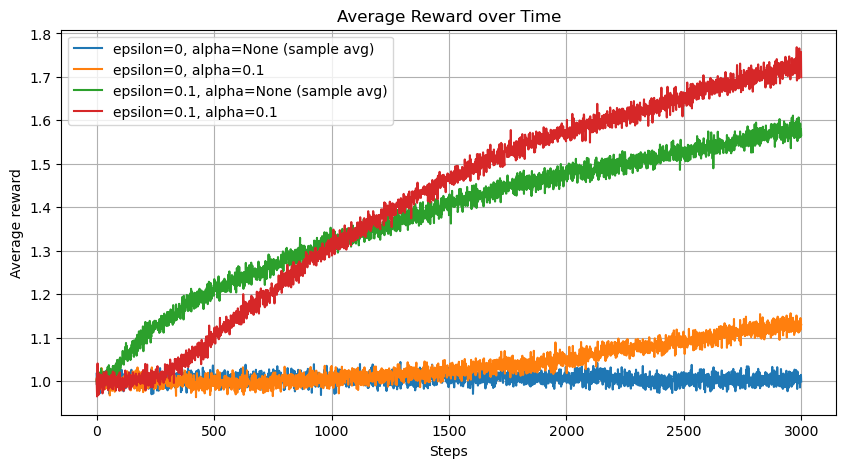

In [27]:
configs_to_plot = list(product(epsilons, alphas))

plt.figure(figsize=(10, 5))

for epsilon, alpha in configs_to_plot:
    plt.plot(
        reward[epsilon, alpha],
        label=label(epsilon, alpha)
    )

plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("Average Reward over Time")
plt.legend()
plt.grid(True)
plt.show()

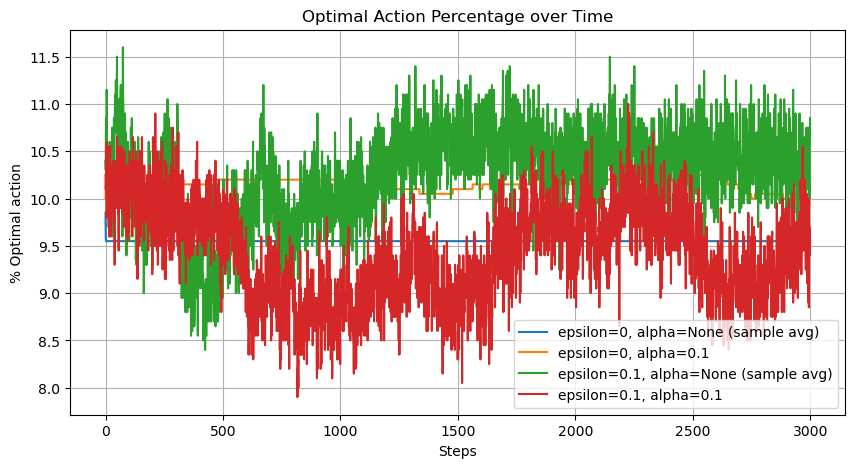

In [28]:
plt.figure(figsize=(10, 5))

for epsilon, alpha in configs_to_plot:
    plt.plot(
        optimal_ratio[epsilon, alpha] * 100,
        label=label(epsilon, alpha)
    )

plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.title("Optimal Action Percentage over Time")
plt.legend()
plt.grid(True)
plt.show()

## Experiment 2: Exploration impact (fixed alphas)

In [29]:
epsilons = [0, 0.01, 0.1, 0.3]

# alpah = None: sample average update --> more recent samples take less weight
# alpha > 0: fixed step update --> more recent samples take more weight
alphas = [0.1] 

reward = {}
optimal_ratio = {}
for epsilon, alpha in product(epsilons, alphas):
    r, o = run_experiments(config.k, epsilon, bandits, alpha, 3000, 2000)
    reward[epsilon, alpha] = np.mean(r, axis=0)
    optimal_ratio[epsilon, alpha] = np.mean(o, axis=0)

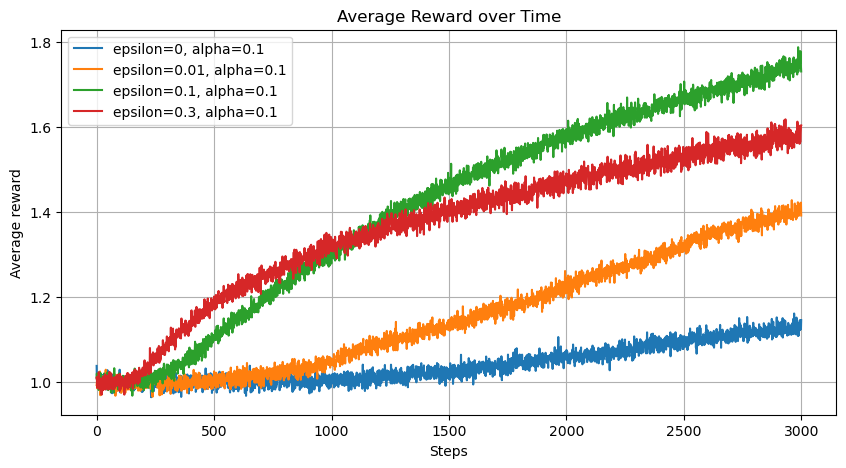

In [30]:
configs_to_plot = list(product(epsilons, alphas))

plt.figure(figsize=(10, 5))

for epsilon, alpha in configs_to_plot:
    plt.plot(
        reward[epsilon, alpha],
        label=label(epsilon, alpha)
    )

plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("Average Reward over Time")
plt.legend()
plt.grid(True)
plt.show()

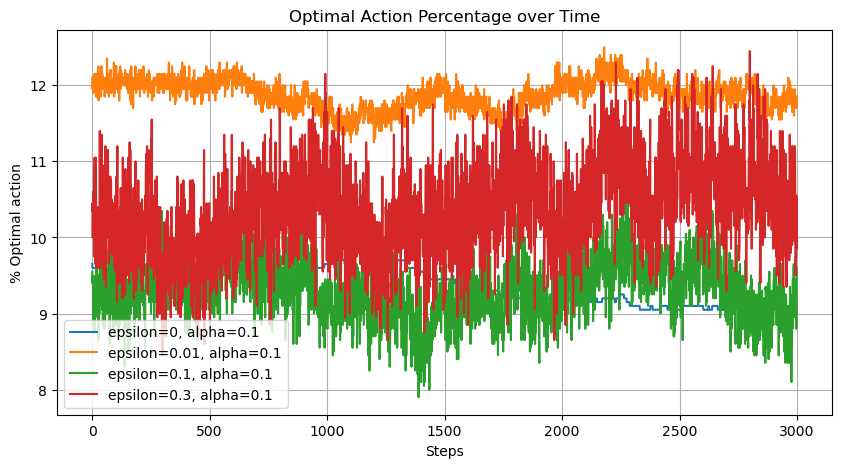

In [31]:
plt.figure(figsize=(10, 5))

for epsilon, alpha in configs_to_plot:
    plt.plot(
        optimal_ratio[epsilon, alpha] * 100,
        label=label(epsilon, alpha)
    )

plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.title("Optimal Action Percentage over Time")
plt.legend()
plt.grid(True)
plt.show()

## Experiment 3: Step size (alpha) impact

In [35]:
epsilons = [0.1]

# alpah = None: sample average update --> more recent samples take less weight
# alpha > 0: fixed step update --> more recent samples take more weight
alphas = [0.01, 0.1, 0.3, 0.5, 1.0] 

reward = {}
optimal_ratio = {}
for epsilon, alpha in product(epsilons, alphas):
    r, o = run_experiments(config.k, epsilon, bandits, alpha, 3000, 2000)
    reward[epsilon, alpha] = np.mean(r, axis=0)
    optimal_ratio[epsilon, alpha] = np.mean(o, axis=0)

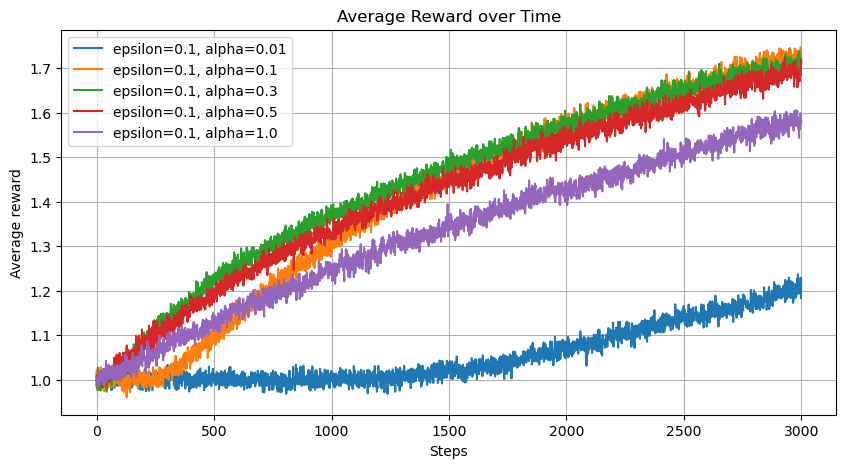

In [36]:
configs_to_plot = list(product(epsilons, alphas))

plt.figure(figsize=(10, 5))

for epsilon, alpha in configs_to_plot:
    plt.plot(
        reward[epsilon, alpha],
        label=label(epsilon, alpha)
    )

plt.xlabel("Steps")
plt.ylabel("Average reward")
plt.title("Average Reward over Time")
plt.legend()
plt.grid(True)
plt.show()

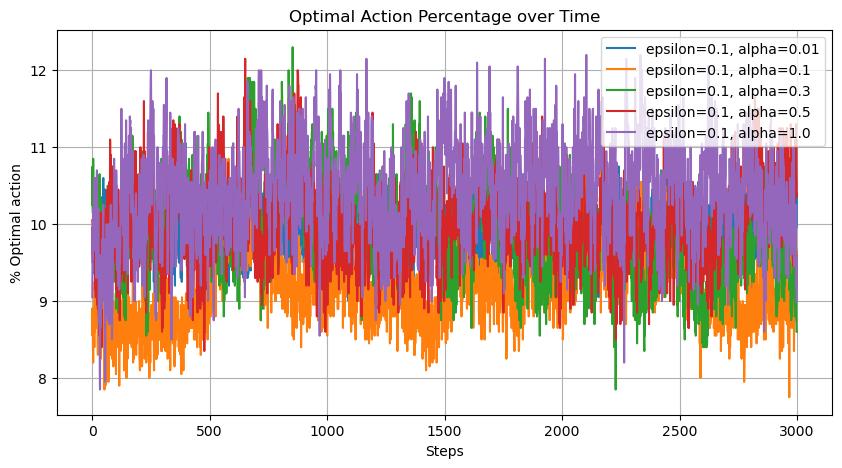

In [37]:
plt.figure(figsize=(10, 5))

for epsilon, alpha in configs_to_plot:
    plt.plot(
        optimal_ratio[epsilon, alpha] * 100,
        label=label(epsilon, alpha)
    )

plt.xlabel("Steps")
plt.ylabel("% Optimal action")
plt.title("Optimal Action Percentage over Time")
plt.legend()
plt.grid(True)
plt.show()